In [1]:
import torch
import torch.nn.functional as F
# 导入 PyG 自带的数据集加载器和图卷积层
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# ==========================================
# 1. 数据准备 (Data Loading)
# ==========================================
# 自动下载 Cora 数据集。Cora 包含 2708 个节点（论文），1433维特征，7个类别。
print("正在加载 Cora 数据集...")
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]  # 因为只有一张完整的图，所以取第 0 个元素

# ==========================================
# 2. 模型定义 (Model Definition - 对应课件 Page 8)
# ==========================================
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345) # 课件中固定的随机种子
        
        # 定义两层 GCN。
        # 第一层：输入维度 1433 -> 隐藏层维度 16
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        # 第二层：隐藏层维度 16 -> 输出类别数 7
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        # x 是节点特征 (X)，edge_index 是图的拓扑结构 (A 的稀疏表示)
        
        # 第一层 Message Passing: 聚合 + 更新
        x = self.conv1(x, edge_index)
        x = x.relu() # 非线性激活
        x = F.dropout(x, p=0.5, training=self.training) # Dropout 防止过拟合
        
        # 第二层 Message Passing: 输出 7 维的 logits
        x = self.conv2(x, edge_index)
        return x

# ==========================================
# 3. 初始化与优化器 (Initialization)
# ==========================================
model = GCN(hidden_channels=16)
print("模型结构如下：\n", model)

# 使用 Adam 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# ==========================================
# 4. 训练与测试逻辑 (Training & Testing Loops)
# ==========================================
def train():
    model.train()           # 设置为训练模式 (启用 Dropout)
    optimizer.zero_grad()   # 梯度清零
    
    # 前向传播：把所有的节点和边扔进模型
    out = model(data.x, data.edge_index)  
    
    # 【核心！】半监督学习：我们只计算训练集节点 (train_mask) 的 Loss
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    
    loss.backward()         # 反向传播
    optimizer.step()        # 更新权重
    return loss.item()

def test():
    model.eval()            # 设置为评估模式 (关闭 Dropout)
    # 前向传播
    out = model(data.x, data.edge_index)
    # 找到每个节点概率最大的类别作为预测结果
    pred = out.argmax(dim=1)
    
    # 提取测试集 (test_mask) 的预测结果与真实标签进行比对
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

# ==========================================
# 5. 开始训练！
# ==========================================
print("\n开始训练 GCN 模型...")
for epoch in range(1, 201):  # 按照课件图表跑 200 个 Epoch
    loss = train()
    if epoch % 20 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

# 测试最终准确率
test_acc = test()
print(f'\n============================')
print(f'GCN 测试集最终准确率 (Test Accuracy): {test_acc:.4f}')
print(f'============================')

正在加载 Cora 数据集...


Processing...
Done!


模型结构如下：
 GCN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
)

开始训练 GCN 模型...
Epoch: 020, Loss: 0.3213
Epoch: 040, Loss: 0.0560
Epoch: 060, Loss: 0.0389
Epoch: 080, Loss: 0.0589
Epoch: 100, Loss: 0.0497
Epoch: 120, Loss: 0.0493
Epoch: 140, Loss: 0.0208
Epoch: 160, Loss: 0.0361
Epoch: 180, Loss: 0.0302
Epoch: 200, Loss: 0.0190

GCN 测试集最终准确率 (Test Accuracy): 0.8100


In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
# 引入 GAT 算子（核心改变！）
from torch_geometric.nn import GATConv

# ==========================================
# 1. 数据准备 (与之前完全一样)
# ==========================================
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

# ==========================================
# 2. 模型定义 (从 GCN 进化为 GAT)
# ==========================================
class GAT(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GAT, self).__init__()
        torch.manual_seed(12345)
        
        # 第一层 GAT：引入多头注意力机制 (Multi-head Attention)
        # heads=8 表示 8 个注意力头并行计算，输出维度会变成 hidden_channels * 8
        self.conv1 = GATConv(dataset.num_features, hidden_channels, heads=8, dropout=0.6)
        
        # 第二层 GAT：将 8 个头的输出汇总，输出 7 个类别
        # concat=False 表示最后一层我们是对多头结果求平均，而不是拼接
        self.conv2 = GATConv(hidden_channels * 8, dataset.num_classes, heads=1, concat=False, dropout=0.6)

    def forward(self, x, edge_index):
        # 官方标准的 GAT 通常使用 Dropout 防止过拟合
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x) # 注意：GAT 官方推荐使用 ELU 激活函数，而不是 ReLU
        
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# ==========================================
# 3. 初始化与优化器
# ==========================================
# GAT 的隐藏层维度通常设小一点（比如 8），因为有 8 个头同时在算
model = GAT(hidden_channels=8)
print("模型结构如下：\n", model)

# GAT 对学习率稍微敏感一点，官方推荐 0.005
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-5)
criterion = torch.nn.CrossEntropyLoss()

# ==========================================
# 4. 训练与测试逻辑 (完全复用 GCN 的代码，一行都不用改！)
# ==========================================
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

# ==========================================
# 5. 开始训练！
# ==========================================
print("\n开始训练 GAT 模型...")
for epoch in range(1, 501):
    loss = train()
    if epoch % 20 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

test_acc = test()
print(f'\n============================')
print(f'GAT 测试集最终准确率 (Test Accuracy): {test_acc:.4f}')
print(f'============================')

模型结构如下：
 GAT(
  (conv1): GATConv(1433, 8, heads=8)
  (conv2): GATConv(64, 7, heads=1)
)

开始训练 GAT 模型...
Epoch: 020, Loss: 0.9541
Epoch: 040, Loss: 0.7693
Epoch: 060, Loss: 0.5704
Epoch: 080, Loss: 0.5812
Epoch: 100, Loss: 0.4194
Epoch: 120, Loss: 0.4420
Epoch: 140, Loss: 0.3708
Epoch: 160, Loss: 0.3794
Epoch: 180, Loss: 0.3726
Epoch: 200, Loss: 0.3091
Epoch: 220, Loss: 0.2909
Epoch: 240, Loss: 0.2995
Epoch: 260, Loss: 0.3963
Epoch: 280, Loss: 0.3150
Epoch: 300, Loss: 0.3092
Epoch: 320, Loss: 0.2643
Epoch: 340, Loss: 0.5031
Epoch: 360, Loss: 0.2995
Epoch: 380, Loss: 0.2468
Epoch: 400, Loss: 0.3675
Epoch: 420, Loss: 0.3412
Epoch: 440, Loss: 0.3344
Epoch: 460, Loss: 0.2983
Epoch: 480, Loss: 0.3007
Epoch: 500, Loss: 0.3764

GAT 测试集最终准确率 (Test Accuracy): 0.7910



正在使用 t-SNE 降维并绘制星空图，请稍候 (大约需要 5-10 秒)...


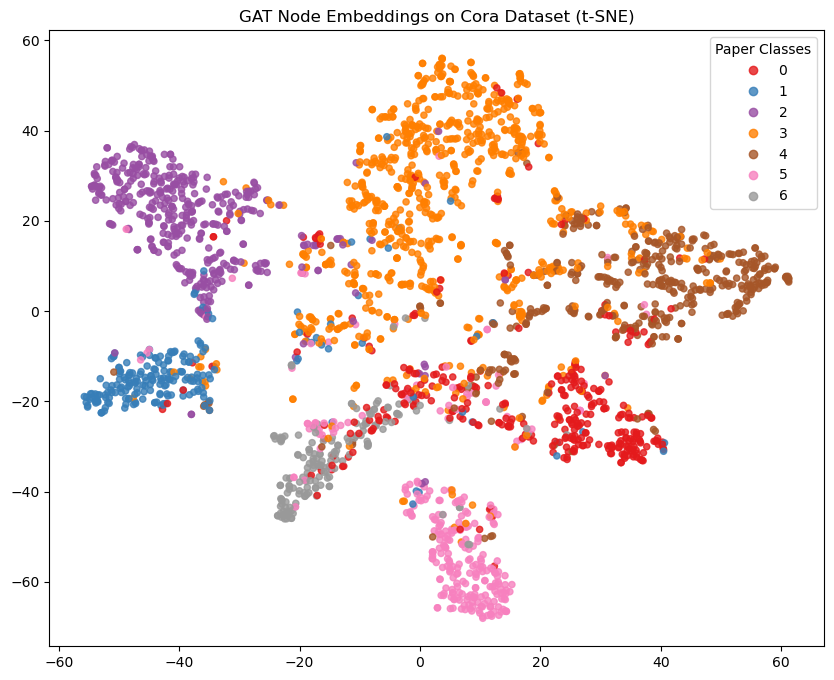

In [4]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

print("\n正在使用 t-SNE 降维并绘制星空图，请稍候 (大约需要 5-10 秒)...")

# 1. 把所有节点送进训练好的模型，提取输出特征
model.eval()
# 这里 .detach().numpy() 是把数据从 PyTorch 张量变成普通的 Numpy 数组，方便画图
out_features = model(data.x, data.edge_index).detach().numpy()

# 2. 使用 t-SNE 将 7 维特征降维到 2 维 (x, y) 坐标
tsne = TSNE(n_components=2, random_state=42)
out_tsne = tsne.fit_transform(out_features)

# 3. 开始用 Matplotlib 画图！
plt.figure(figsize=(10, 8))

# 获取每个节点的真实标签 (0-6)
labels = data.y.numpy()

# 画散点图，c=labels 表示用不同的类别画不同的颜色，cmap 是配色方案
scatter = plt.scatter(out_tsne[:, 0], out_tsne[:, 1], c=labels, cmap='Set1', s=20, alpha=0.8)

# 添加图例和标题
plt.legend(*scatter.legend_elements(), title="Paper Classes")
plt.title("GAT Node Embeddings on Cora Dataset (t-SNE)")

# 显示图像
plt.show()